# Module — Fama-French 3-Factor Model
## Notebook 5 (teaching edition): Decomposing a stock's returns into market, size, and value factors

In Notebook 4 we ran the **CAPM / market model**:

$$
r_i - r_f \;=\; \alpha \;+\; \beta_{\text{MKT}}\,(r_m - r_f) \;+\; \varepsilon
$$

That's a **one-factor model** — we explain a stock's excess return with one variable (the market excess return). Fama and French (1993) showed empirically that a simple two-factor extension — adding a **size** factor and a **value** factor — explains more of the cross-section of stock returns than CAPM alone. The **FF3 regression** is

$$
r_i - r_f \;=\; \alpha \;+\; \beta_{\text{MKT}}\,(r_m - r_f) \;+\; \beta_{\text{SMB}}\cdot \text{SMB} \;+\; \beta_{\text{HML}}\cdot \text{HML} \;+\; \varepsilon
$$

where
- **SMB** (Small Minus Big) — the return spread between small-cap and large-cap portfolios.
- **HML** (High Minus Low) — the return spread between value stocks (high book-to-market) and growth stocks (low book-to-market).

The coefficients $\beta_{\text{SMB}}$ and $\beta_{\text{HML}}$ are the stock's **exposures** to these factors:
- $\beta_{\text{SMB}} > 0$ → behaves like a small-cap stock; $\beta_{\text{SMB}} < 0$ → like a large-cap.
- $\beta_{\text{HML}} > 0$ → value-like; $\beta_{\text{HML}} < 0$ → growth-like.

We walk through the full analysis for **Reliance Industries (RELIANCE_NS)** using the monthly data we downloaded in Notebook 0. The code is written so that swapping to any other ticker requires a **one-line change** at the top of the notebook.


## 0. Imports and configuration

Everything downstream uses the variables defined here. **To run this notebook on a different stock, change only `STOCK_FILE`.**


In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 4)
pd.set_option('display.precision', 4)

# Generic — change this one line to re-run for any stock in ./monthly/
STOCK_FILE   = 'datasets/monthly/RELIANCE_NS.csv'
FACTORS_FILE = 'datasets/others/famafactors.csv'


## 1. Load the stock's monthly data

The files in `./monthly/` were produced by Notebook 0. Each one has monthly OHLCV from yfinance, already split/dividend adjusted.


### 1.1  Read the CSV


In [10]:
stock_raw = pd.read_csv(STOCK_FILE, index_col='Date', parse_dates=True)
print(f'Loaded: {STOCK_FILE}')
print(f'Shape: {stock_raw.shape}')
stock_raw.head()


Loaded: datasets/monthly/RELIANCE_NS.csv
Shape: (60, 5)


,Close,High,Low,Open,Volume
Date,,,,,
2021-05-01,979.5475,993.7852,864.2400,891.4458,374374485
2021-06-01,957.0347,1031.5108,943.5905,982.1321,503558070
2021-07-01,926.0861,979.8912,917.4180,963.7155,215416700
2021-08-01,1027.4855,1039.1337,928.7479,934.7313,282080043
2021-09-01,1146.2889,1169.3808,1026.0521,1034.2423,328996430


### 1.2  Keep only the Close price and compute monthly simple returns

Use `pct_change()` on Close to get $r_t = (P_t - P_{t-1}) / P_{t-1}$, then convert to **percent** so the units match the Fama-French factors (which are in percent).


In [11]:
stock_returns = (stock_raw['Close'].pct_change() * 100).dropna()
stock_returns.name = 'stock_ret'
print(f'Monthly return observations: {len(stock_returns)}')
print(f'Date range: {stock_returns.index.min().date()} to {stock_returns.index.max().date()}')
stock_returns.head()


Monthly return observations: 59
Date range: 2021-06-01 to 2026-04-01


Date
2021-06-01    -2.2983
2021-07-01    -3.2338
2021-08-01    10.9492
2021-09-01    11.5625
2021-10-01     0.6748
Name: stock_ret, dtype: float64

The first row is dropped (no prior month to compute a return against), so we have $n - 1$ observations.


## 2. Load the Fama-French factors


### 2.1  Read the CSV and parse the monthly date


In [12]:
factors_raw = pd.read_csv(FACTORS_FILE)
print(f'Shape: {factors_raw.shape}')
print(f'Columns: {list(factors_raw.columns)}')
factors_raw.head()


Shape: (387, 6)
Columns: ['Date', 'SMB', 'HML', 'WML', 'MF', 'RF']


,Date,SMB,HML,WML,MF,RF
0,1993-10,2.9807,2.5872,3.0111,NaN,NaN
1,1993-11,-9.4227,-0.5586,12.6212,17.6219,0.6114
2,1993-12,-3.7740,7.5534,-3.3045,8.2922,0.6130
3,1994-01,5.3005,-4.1863,-5.0990,18.7178,0.8568
4,1994-02,3.6394,-2.5724,5.0620,4.8869,0.6200


### 2.2  Parse `Date` (`YYYY-MM`) to a month-end timestamp

Using `pd.to_datetime(..., format='%Y-%m')` gives us the first day of each month. That matches the yfinance monthly data (whose timestamps are also first-of-month), so we can align the two without extra conversion.


In [13]:
factors_raw['Date'] = pd.to_datetime(factors_raw['Date'], format='%Y-%m')
factors_raw = factors_raw.set_index('Date').sort_index()
factors_raw.head()


,SMB,HML,WML,MF,RF
Date,,,,,
1993-10-01,2.9807,2.5872,3.0111,NaN,NaN
1993-11-01,-9.4227,-0.5586,12.6212,17.6219,0.6114
1993-12-01,-3.7740,7.5534,-3.3045,8.2922,0.6130
1994-01-01,5.3005,-4.1863,-5.0990,18.7178,0.8568
1994-02-01,3.6394,-2.5724,5.0620,4.8869,0.6200


### 2.3  What do the columns mean?

From the source of this file:

| Column | Meaning |
|---|---|
| `MF`  | Market Factor — the **market excess return** $(r_m - r_f)$, in percent |
| `SMB` | Small Minus Big — size factor, in percent |
| `HML` | High Minus Low — value factor, in percent |
| `RF`  | Monthly risk-free rate, in percent |

We will use **MF, SMB, HML, RF**. `WML` is kept in the exercises for a Carhart 4-factor extension.


For Indian Fama-French factor datasets (IIMB / NSE conventions), `MF` is conventionally already the **market excess return**. We'll treat it as such — and use it directly as the market factor in the regression, without subtracting `RF`.


## 3. Build the regression dataset by aligning on month

Both series are indexed by first-of-month timestamps. Joining them on the index automatically aligns by month. Rows where either side is missing get dropped.


In [14]:
# Drop rows where any of the core columns is NaN (first row has MF/RF missing)
factors_clean = factors_raw[['MF', 'SMB', 'HML', 'RF']].dropna()

# Join the stock return series with the three factors and the risk-free rate
data = pd.concat(
    [stock_returns, factors_clean[['MF', 'SMB', 'HML', 'RF']]],
    axis=1,
    join='inner',    # keep only months present in both datasets
).dropna()

print(f'Regression sample: {len(data)} months')
print(f'Range: {data.index.min().date()} to {data.index.max().date()}')
data.head()


Regression sample: 55 months
Range: 2021-06-01 to 2025-12-01


,stock_ret,MF,SMB,HML,RF
Date,,,,,
2021-06-01,-2.2983,3.0547,7.8134,4.3821,0.2778
2021-07-01,-3.2338,1.7369,5.2969,7.1290,0.2776
2021-08-01,10.9492,5.6798,-8.1047,-7.1379,0.2898
2021-09-01,11.5625,4.1872,-1.6146,10.3894,0.2678
2021-10-01,0.6748,-1.1338,1.6854,0.6467,0.2697


### 3.1  Compute the stock's excess return

The left-hand side of the FF3 regression is $r_i - r_f$ (the stock's return above the risk-free rate).


In [15]:
data['stock_ex'] = data['stock_ret'] - data['RF']
data[['stock_ret', 'RF', 'stock_ex', 'MF', 'SMB', 'HML']].head()


,stock_ret,RF,stock_ex,MF,SMB,HML
Date,,,,,,
2021-06-01,-2.2983,0.2778,-2.5761,3.0547,7.8134,4.3821
2021-07-01,-3.2338,0.2776,-3.5114,1.7369,5.2969,7.1290
2021-08-01,10.9492,0.2898,10.6594,5.6798,-8.1047,-7.1379
2021-09-01,11.5625,0.2678,11.2947,4.1872,-1.6146,10.3894
2021-10-01,0.6748,0.2697,0.4051,-1.1338,1.6854,0.6467


## 4. Exploratory look — how does the stock move with each factor?


### 4.1  Time series of stock excess return and the three factors


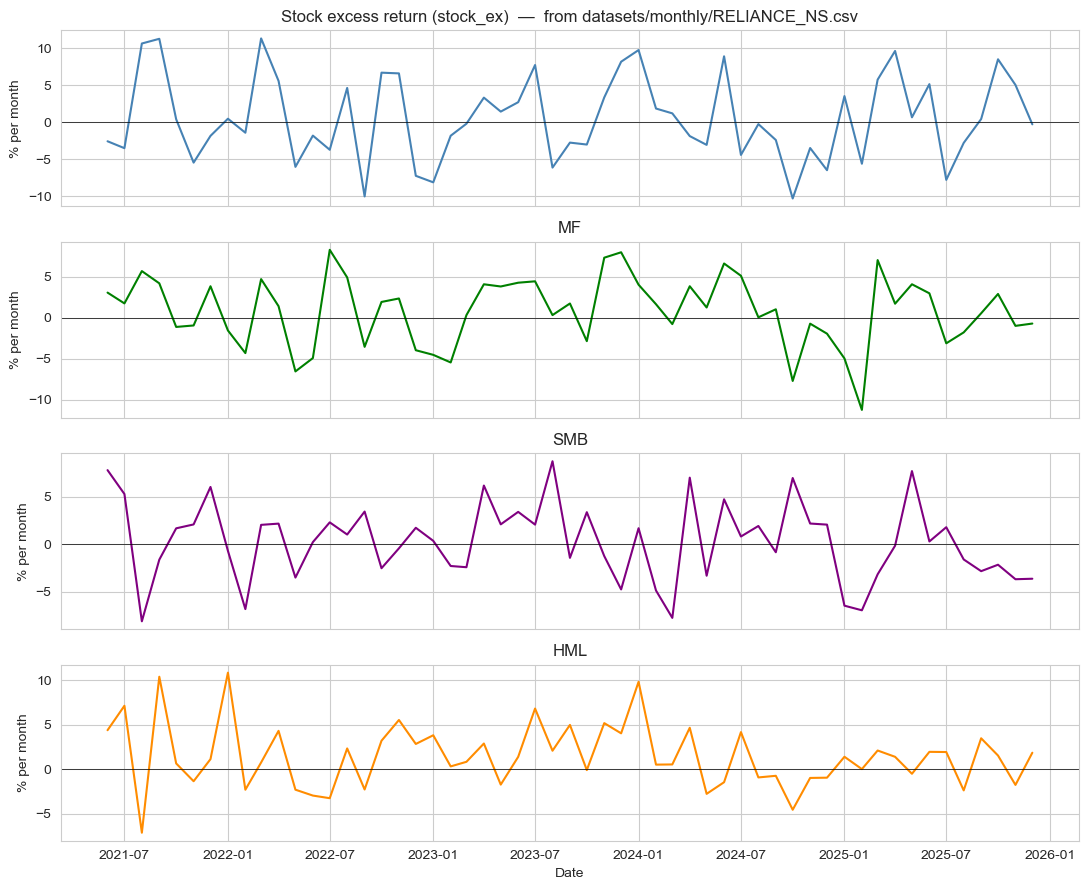

In [16]:
fig, axes = plt.subplots(4, 1, figsize=(11, 9), sharex=True)

axes[0].plot(data.index, data['stock_ex'], color='steelblue')
axes[0].axhline(0, color='black', lw=0.5)
axes[0].set_title(f'Stock excess return (stock_ex)  —  from {STOCK_FILE}')
axes[0].set_ylabel('% per month')

for ax, col, color in zip(axes[1:],
                           ['MF', 'SMB', 'HML'],
                           ['green', 'purple', 'darkorange']):
    ax.plot(data.index, data[col], color=color)
    ax.axhline(0, color='black', lw=0.5)
    ax.set_title(col)
    ax.set_ylabel('% per month')

axes[-1].set_xlabel('Date')
plt.tight_layout()
plt.show()


### 4.2  Correlation between stock excess return and each factor


In [17]:
corr = data[['stock_ex', 'MF', 'SMB', 'HML']].corr()
corr


,stock_ex,MF,SMB,HML
stock_ex,1.0000,0.6125,-0.2611,0.2927
MF,0.6125,1.0000,0.1926,0.2739
SMB,-0.2611,0.1926,1.0000,0.1314
HML,0.2927,0.2739,0.1314,1.0000


The `stock_ex` row shows the correlation between this stock's excess return and each factor. A strong correlation with `MF` is expected — every stock moves with the market to some degree. Correlations with `SMB` and `HML` tell us how tilted the stock is toward size and value, respectively.


### 4.3  Scatter plots — stock_ex vs each factor


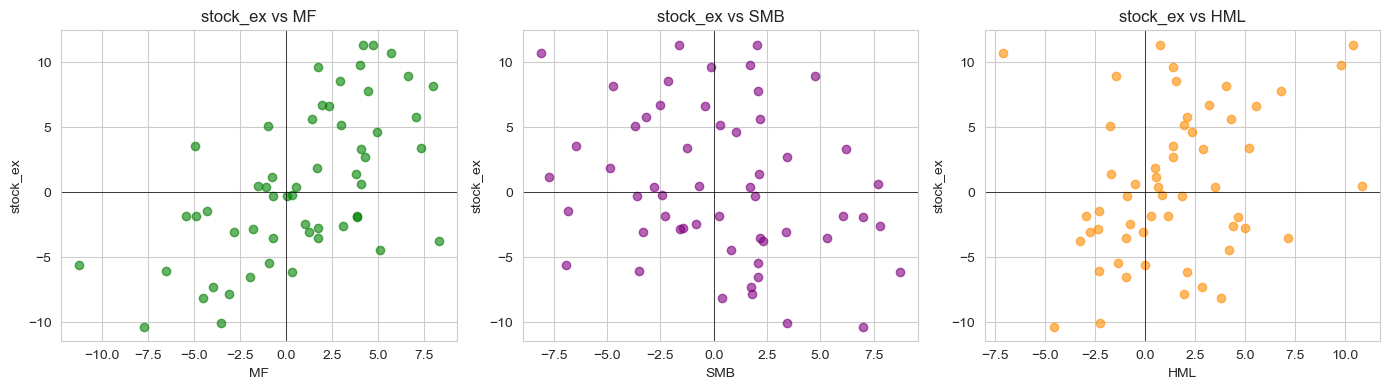

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, col, color in zip(axes,
                           ['MF', 'SMB', 'HML'],
                           ['green', 'purple', 'darkorange']):
    ax.scatter(data[col], data['stock_ex'], alpha=0.6, color=color)
    ax.axhline(0, color='black', lw=0.5)
    ax.axvline(0, color='black', lw=0.5)
    ax.set_xlabel(col)
    ax.set_ylabel('stock_ex')
    ax.set_title(f'stock_ex vs {col}')

plt.tight_layout()
plt.show()


## 5. Baseline — the CAPM / 1-factor regression

Before adding SMB and HML, let's reproduce the market-model regression from Notebook 4:

$$
\text{stock\_ex} = \alpha + \beta_{\text{MKT}}\cdot \text{MF} + \varepsilon
$$

We'll use **`statsmodels.formula.api`** — the formula notation (`y ~ x1 + x2`) is very readable and automatically adds an intercept.


In [20]:
capm_result = smf.ols('stock_ex ~ MF', data=data).fit()
print(capm_result.summary())


                            OLS Regression Results                            
Dep. Variable:               stock_ex   R-squared:                       0.375
Model:                            OLS   Adj. R-squared:                  0.363
Method:                 Least Squares   F-statistic:                     31.82
Date:                Sun, 26 Apr 2026   Prob (F-statistic):           6.70e-07
Time:                        21:45:06   Log-Likelihood:                -160.78
No. Observations:                  55   AIC:                             325.6
Df Residuals:                      53   BIC:                             329.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.1294      0.630     -0.205      0.8

The summary table is the standard statsmodels output — lots of fields, but the key ones are:

- **coef** — the estimates $\hat{\alpha}$ (row `Intercept`) and $\hat{\beta}_{\text{MKT}}$ (row `MF`).
- **std err** — standard error of the estimate.
- **t** — t-statistic (coef ÷ std err).
- **P>|t|** — two-sided p-value for $H_0: \text{coef} = 0$.
- **R-squared** — fraction of variance in `stock_ex` explained by the model.

Let's pull out the headline numbers explicitly.


In [21]:
print(f'CAPM (1-factor) for {STOCK_FILE}:')
print(f'  alpha      = {capm_result.params["Intercept"]:+.4f}   (SE = {capm_result.bse["Intercept"]:.4f}, p = {capm_result.pvalues["Intercept"]:.4f})')
print(f'  beta_MKT   = {capm_result.params["MF"]:+.4f}        (SE = {capm_result.bse["MF"]:.4f}, p = {capm_result.pvalues["MF"]:.4f})')
print(f'  R²         = {capm_result.rsquared:.4f}')
print(f'  Adj R²     = {capm_result.rsquared_adj:.4f}')


CAPM (1-factor) for datasets/monthly/RELIANCE_NS.csv:
  alpha      = -0.1294   (SE = 0.6300, p = 0.8381)
  beta_MKT   = +0.8367        (SE = 0.1483, p = 0.0000)
  R²         = 0.3752
  Adj R²     = 0.3634


## 6. The Fama-French 3-factor regression

Now add SMB and HML:

$$
\text{stock\_ex} = \alpha + \beta_{\text{MKT}}\cdot \text{MF} + \beta_{\text{SMB}}\cdot \text{SMB} + \beta_{\text{HML}}\cdot \text{HML} + \varepsilon
$$

Same function call, one longer formula.


In [22]:
ff3_result = smf.ols('stock_ex ~ MF + SMB + HML', data=data).fit()
print(ff3_result.summary())


                            OLS Regression Results                            
Dep. Variable:               stock_ex   R-squared:                       0.551
Model:                            OLS   Adj. R-squared:                  0.525
Method:                 Least Squares   F-statistic:                     20.86
Date:                Sun, 26 Apr 2026   Prob (F-statistic):           5.93e-09
Time:                        21:45:25   Log-Likelihood:                -151.70
No. Observations:                  55   AIC:                             311.4
Df Residuals:                      51   BIC:                             319.4
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.3921      0.580     -0.677      0.5

## 7. CAPM vs FF3 — what did the extra factors buy us?


In [24]:
compare = pd.DataFrame({
    'CAPM':  {
        'alpha':       capm_result.params['Intercept'],
        'alpha_p':     capm_result.pvalues['Intercept'],
        'beta_MKT':    capm_result.params['MF'],
        'beta_MKT_p':  capm_result.pvalues['MF'],
        'beta_SMB':    np.nan,
        'beta_SMB_p':  np.nan,
        'beta_HML':    np.nan,
        'beta_HML_p':  np.nan,
        'R²':          capm_result.rsquared,
        'Adj R²':      capm_result.rsquared_adj,
    },
    'FF3':   {
        'alpha':       ff3_result.params['Intercept'],
        'alpha_p':     ff3_result.pvalues['Intercept'],
        'beta_MKT':    ff3_result.params['MF'],
        'beta_MKT_p':  ff3_result.pvalues['MF'],
        'beta_SMB':    ff3_result.params['SMB'],
        'beta_SMB_p':  ff3_result.pvalues['SMB'],
        'beta_HML':    ff3_result.params['HML'],
        'beta_HML_p':  ff3_result.pvalues['HML'],
        'R²':          ff3_result.rsquared,
        'Adj R²':      ff3_result.rsquared_adj,
    },
}).T
compare


,alpha,alpha_p,beta_MKT,beta_MKT_p,beta_SMB,beta_SMB_p,beta_HML,beta_HML_p,R²,Adj R²
CAPM,-0.1294,0.8381,0.8367,6.6953e-07,NaN,NaN,NaN,NaN,0.3752,0.3634
FF3,-0.3921,0.5017,0.8805,3.1591e-08,-0.5697,9.1655e-05,0.2708,0.089,0.5509,0.5245


**What to look at**

- **Does $R^2$ improve?** If so, the new factors are capturing variance in the stock's return that the market alone missed.
- **Does Adjusted $R^2$ improve?** Plain $R^2$ always goes up when you add regressors — adjusted $R^2$ penalises for extra parameters and is the fairer comparison.
- **Does alpha change?** If alpha shrinks toward zero (or its p-value rises), then apparent CAPM alpha was being driven by SMB/HML exposures rather than genuine skill.
- **Which new factors are significant?** A p-value below 0.05 on SMB or HML says the stock has a real, non-zero tilt toward that style.


## 8. Interpreting the coefficients


In [17]:
alpha      = ff3_result.params['Intercept']
beta_mkt   = ff3_result.params['MF']
beta_smb   = ff3_result.params['SMB']
beta_hml   = ff3_result.params['HML']

print(f'Interpretation for {STOCK_FILE}:\n')

print(f'Market beta:   {beta_mkt:+.3f}')
if beta_mkt > 1.05:
    print('  → Aggressive — moves more than the market.')
elif beta_mkt < 0.95:
    print('  → Defensive — moves less than the market.')
else:
    print('  → Roughly market-like.')

print(f'\nSMB beta:      {beta_smb:+.3f}')
if beta_smb > 0.1:
    print('  → Positive size tilt — behaves like a small-cap stock.')
elif beta_smb < -0.1:
    print('  → Negative size tilt — behaves like a large-cap stock.')
else:
    print('  → Roughly size-neutral.')

print(f'\nHML beta:      {beta_hml:+.3f}')
if beta_hml > 0.1:
    print('  → Positive value tilt — behaves like a value stock.')
elif beta_hml < -0.1:
    print('  → Negative value tilt — behaves like a growth stock.')
else:
    print('  → Roughly style-neutral.')

print(f'\nAlpha:         {alpha:+.4f}% per month')
alpha_annual = ((1 + alpha/100) ** 12 - 1) * 100
print(f'               {alpha_annual:+.3f}% per year (compounded)')
if ff3_result.pvalues['Intercept'] < 0.05:
    print('  → Statistically distinguishable from zero at the 5% level.')
else:
    print('  → NOT statistically distinguishable from zero — consistent with efficient pricing.')


Interpretation for monthly/RELIANCE_NS.csv:

Market beta:   +0.880
  → Defensive — moves less than the market.

SMB beta:      -0.570
  → Negative size tilt — behaves like a large-cap stock.

HML beta:      +0.271
  → Positive value tilt — behaves like a value stock.

Alpha:         -0.3921% per month
               -4.605% per year (compounded)
  → NOT statistically distinguishable from zero — consistent with efficient pricing.


**How to read this**

- A stock with $\beta_{\text{MKT}} \approx 1$ and $\beta_{\text{SMB}} < 0$ is behaving like a standard large-cap — moves with the market, size-tilted toward large.
- A positive, statistically significant alpha is a very strong claim — the stock returned more than its market, size, and value exposures alone would justify. With ~55 monthly observations this is almost always indistinguishable from zero.
- Coefficients are interpretable by the sign and magnitude. But **their standard errors matter** — a nominally large tilt with a huge SE tells you the sample is just not informative about that exposure.


## 9. Residual diagnostics

The regression assumes residuals that are (a) zero-mean, (b) roughly constant variance, (c) roughly normal, (d) uncorrelated with the regressors. Two quick plots to check.


### 9.1  Residuals vs fitted values

A scatter of residuals against fitted values should look like a random cloud around zero with no pattern. A trumpet shape would signal heteroskedasticity; curvature would signal a missing non-linear term.


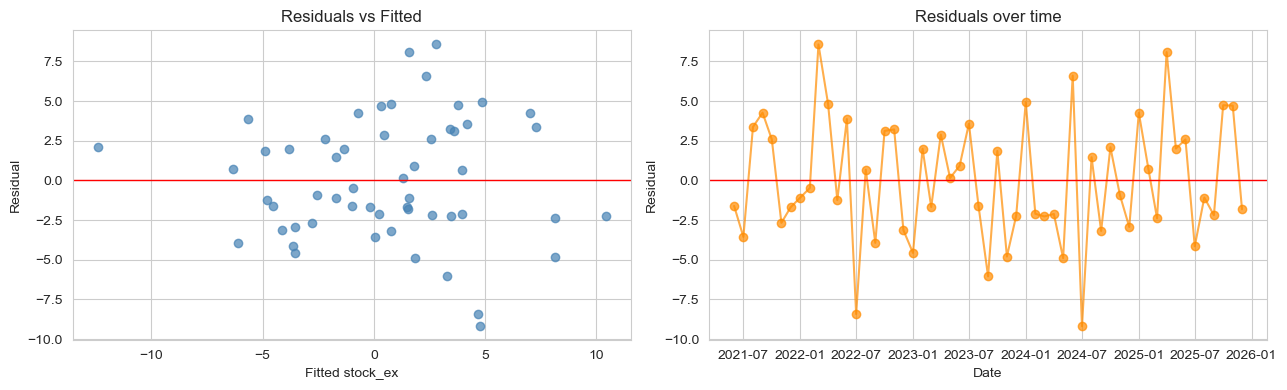

In [25]:
fitted    = ff3_result.fittedvalues
residuals = ff3_result.resid

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].scatter(fitted, residuals, alpha=0.7, color='steelblue')
axes[0].axhline(0, color='red', lw=1)
axes[0].set_xlabel('Fitted stock_ex')
axes[0].set_ylabel('Residual')
axes[0].set_title('Residuals vs Fitted')

axes[1].plot(residuals.index, residuals, 'o-', color='darkorange', alpha=0.7)
axes[1].axhline(0, color='red', lw=1)
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Residual')
axes[1].set_title('Residuals over time')

plt.tight_layout()
plt.show()


### 9.2  Histogram of residuals


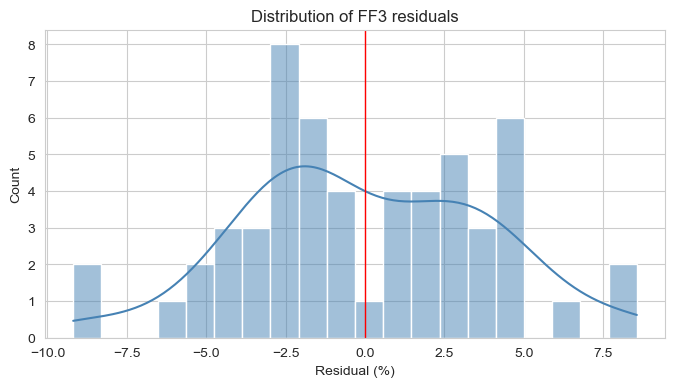

In [26]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(residuals, bins=20, kde=True, ax=ax, color='steelblue')
ax.axvline(0, color='red', lw=1)
ax.set_xlabel('Residual (%)')
ax.set_title('Distribution of FF3 residuals')
plt.show()


Most-stock residuals with ~50 observations look noisy — with so few points you can't cleanly detect non-normality. What you **can** detect is egregious outliers (a single residual at 3σ+ flags a month that the factor model can't explain).


---

## Summary

We ran a **Fama-French 3-factor regression** for one stock (`STOCK_FILE`), using:

- **Monthly adjusted closing prices** from `monthly/<TICKER>_NS.csv` (downloaded in Notebook 0).
- The **Indian FF/Carhart factor file** `famafactors.csv` (MF, SMB, HML, RF, already in percent units).

Key findings from the regression (for the stock currently loaded):

- **Market beta** ($\beta_{\text{MKT}}$) — how much of a market-mover the stock is.
- **Size beta** ($\beta_{\text{SMB}}$) — size tilt (positive = small-like, negative = large-like).
- **Value beta** ($\beta_{\text{HML}}$) — value/growth tilt (positive = value-like, negative = growth-like).
- **Alpha** — monthly excess after market, size, and value exposures are stripped out. Typically statistically indistinguishable from zero with ~55 monthly observations.

To run this entire notebook for any other stock in `./monthly/`, change **one line** at the top:

```python
STOCK_FILE = 'monthly/RELIANCE_NS.csv'   # ← change this
```

and re-execute the notebook.


## End-of-notebook exercises

### Exercise 1 — Swap in a different stock

Change `STOCK_FILE` to `'monthly/TECHM_NS.csv'` at the top and re-run the entire notebook. How do Tech Mahindra's FF3 loadings differ from Reliance's?

- Is Tech Mahindra's $\beta_{\text{MKT}}$ higher or lower?
- Does its sign on SMB / HML differ (tech stocks are often tagged as *growth*, so you might expect $\beta_{\text{HML}} < 0$)?
- Is the FF3 R² higher or lower?

### Exercise 2 — Loop over all 10 stocks

Write a loop over every file in `./monthly/`, run FF3 on each, and build a summary table:

```python
import glob
results = []
for path in glob.glob('monthly/*_NS.csv'):
    # ... load, compute returns, align, run FF3 ...
    results.append({'ticker': ..., 'alpha': ..., 'beta_MKT': ..., ...})
summary = pd.DataFrame(results)
```

Which stocks have significant alpha? Which have the strongest value tilt? Which the strongest size tilt?
